# Tweet Disruption Classification
**TF-IDF + Logistic Regression**

Classifies T1 Sydney train tweets as `cancelled`, `delayed`, or `unknown`.

Pipeline:
1. Load tweets from DynamoDB
2. Label using existing keyword classifier (baseline)
3. EDA
4. Train TF-IDF + Logistic Regression model
5. Evaluate
6. Save model for production use

## 0. Install Dependencies

In [2]:
%pip install boto3 pandas scikit-learn matplotlib seaborn joblib --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load Data from DynamoDB

In [3]:
import boto3
import pandas as pd

TABLE_NAME = "clearpath-alert-data"
AWS_REGION = "us-east-1"  # update if different

dynamodb = boto3.resource("dynamodb", region_name=AWS_REGION)
table = dynamodb.Table(TABLE_NAME)

# Scan all records from DynamoDB
items = []
response = table.scan()
items.extend(response["Items"])

# Handle pagination if table has >1MB of data
while "LastEvaluatedKey" in response:
    response = table.scan(ExclusiveStartKey=response["LastEvaluatedKey"])
    items.extend(response["Items"])

df = pd.DataFrame(items)
print(f"Loaded {len(df)} records")
df.head()

Loaded 361 records


,account_name,classification,date,text,status
0,T1 Sydney Trains,unknown,2024-10-06,#NorthShoreLine Allow extra travel time due to...,"[collected, classified]"
1,T1 Sydney Trains,unknown,2024-12-03,#NorthShoreLine Allow up to 20 minutes extra t...,"[collected, classified]"
2,T1 Sydney Trains,unknown,2025-07-21,⚠ #NorthShoreLine #WesternLine Allow extra tra...,"[collected, classified]"
3,T1 Sydney Trains,unknown,2024-07-22,⚠ #NorthShoreLine #WesternLine Allow extra tra...,"[collected, classified]"
4,T1 Sydney Trains,unknown,2024-11-03,#WesternLine Allow extra travel time due to a ...,"[collected, classified]"


In [6]:
df = df.drop(columns=["classification"], errors="ignore")
# Keep only records with tweet text
df = df[df["text"].notna()].copy()
df["text"] = df["text"].astype(str)
print(f"Records with text: {len(df)}")
df[["date", "text"]].head(10)

Records with text: 361


,date,text
0,2024-10-06,#NorthShoreLine Allow extra travel time due to...
1,2024-12-03,#NorthShoreLine Allow up to 20 minutes extra t...
2,2025-07-21,⚠ #NorthShoreLine #WesternLine Allow extra tra...
3,2024-07-22,⚠ #NorthShoreLine #WesternLine Allow extra tra...
4,2024-11-03,#WesternLine Allow extra travel time due to a ...
5,2025-03-25,⚠ #WesternLine Allow extra travel time due to ...
6,2026-01-21,#NorthShoreLine Allow extra time travelling aw...
7,2024-06-06,#NorthShoreLine Please allow up to 10 minutes ...
8,2024-09-04,Allow extra travel time on #NorthShoreLine and...
9,2024-04-09,#NorthShoreLine &amp; #WesternLine allow up to...


## 2. Label Data Using Claude API

We send each tweet to Claude to get a label: `cancelled`, `delayed`, or `unknown`.

Claude handles phrasing the keyword classifier misses (e.g. 'buses replacing trains', 'no trains operating').

Labels are cached to a CSV so you don't re-spend API calls if you re-run the notebook.

In [7]:
%pip install anthropic --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import anthropic
import time
import os

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")
CACHE_PATH = "labelled_tweets.csv"
VALID_LABELS = {"cancelled", "delayed", "unknown"}

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)


def claude_classify(text: str) -> str:
    """
    Classify a single tweet using Claude.
    Returns one of: cancelled, delayed, unknown.
    """
    prompt = f"""You are classifying tweets from the T1 Sydney train line Twitter account.

Classify the tweet below into exactly one of these categories:
- cancelled  → trains are not running, service suspended, buses replacing trains, line closed
- delayed    → trains are running but late, slow, disrupted, reduced frequency, or partially suspended
- unknown    → normal service, unrelated update, or genuinely unclear

Reply with a single word only: cancelled, delayed, or unknown.

Tweet: {text}"""

    response = client.messages.create(
        model="claude-haiku-4-5-20251001",  # cheapest model — plenty good for this task
        max_tokens=10,
        messages=[{"role": "user", "content": prompt}],
    )
    label = response.content[0].text.strip().lower()
    return label if label in VALID_LABELS else "unknown"


print("Claude API client ready.")

Claude API client ready.


In [9]:
# Load cached labels if they exist — avoids re-calling the API on re-runs
if os.path.exists(CACHE_PATH):
    cached = pd.read_csv(CACHE_PATH, index_col="date")
    df = df.join(cached[["label"]], on="date", how="left")
    already_labelled = df["label"].notna().sum()
    print(f"Loaded {already_labelled} cached labels from {CACHE_PATH}")
else:
    df["label"] = None
    print("No cache found — will label all records.")

to_label = df[df["label"].isna()]
print(f"Tweets to label: {len(to_label)}")

No cache found — will label all records.
Tweets to label: 361


In [10]:
# Label all unlabelled tweets — runs in batches with a small delay to respect rate limits
# At ~100-500 tweets this takes 1-3 minutes and costs a few cents

DELAY_SECONDS = 0.2  # pause between API calls

for i, (idx, row) in enumerate(to_label.iterrows()):
    label = claude_classify(row["text"])
    df.at[idx, "label"] = label

    if (i + 1) % 20 == 0:
        print(f"  Labelled {i + 1}/{len(to_label)}...")

    time.sleep(DELAY_SECONDS)

# Cache results so re-runs don't re-call the API
df[["date", "label"]].to_csv(CACHE_PATH, index=False)
print(f"\nDone. Labels saved to {CACHE_PATH}")
print(df["label"].value_counts())

  Labelled 20/361...
  Labelled 40/361...
  Labelled 60/361...
  Labelled 80/361...
  Labelled 100/361...
  Labelled 120/361...
  Labelled 140/361...
  Labelled 160/361...
  Labelled 180/361...
  Labelled 200/361...
  Labelled 220/361...
  Labelled 240/361...
  Labelled 260/361...
  Labelled 280/361...
  Labelled 300/361...
  Labelled 320/361...
  Labelled 340/361...
  Labelled 360/361...

Done. Labels saved to labelled_tweets.csv
label
delayed      320
cancelled     35
unknown        6
Name: count, dtype: int64


In [11]:
# Spot-check — review a sample to sanity check Claude's labels
df[["text", "label"]].sample(20, random_state=42)

,text,label
163,#NorthShoreLine Allow extra travel time toward...,delayed
33,#NorthShoreLine Allow extra travel time due to...,delayed
15,#NorthShoreLine Limited replacement buses are ...,cancelled
322,#NorthShoreLine Allow extra travel time due to...,delayed
57,"Consider delaying non-essential travel, catchi...",delayed
182,#NorthShoreLine &amp; #WesternLine allow extra...,delayed
76,⚠ #NorthShoreLine Allow 5-10 minutes extra tra...,delayed
119,⚠️ Some #WesternLine trains may be running lat...,delayed
267,#NorthShoreLine Allow extra travel time travel...,delayed
126,⚠ You may also want to consider using local bu...,delayed


In [12]:
# Also keep the keyword classifier for baseline comparison in Section 5
def keyword_classify(text: str) -> str:
    """Original keyword classifier — used as baseline for comparison only."""
    text = text.lower()
    cancelled_keywords = ["cancelled", "canceled", "suspended", "no service", "not running", "shutdown", "closed"]
    delayed_keywords = ["delayed", "delay", "slow", "disruption", "late", "reduced", "minor delays", "part suspended"]
    for kw in cancelled_keywords:
        if kw in text:
            return "cancelled"
    for kw in delayed_keywords:
        if kw in text:
            return "delayed"
    return "unknown"

## 3. Exploratory Data Analysis

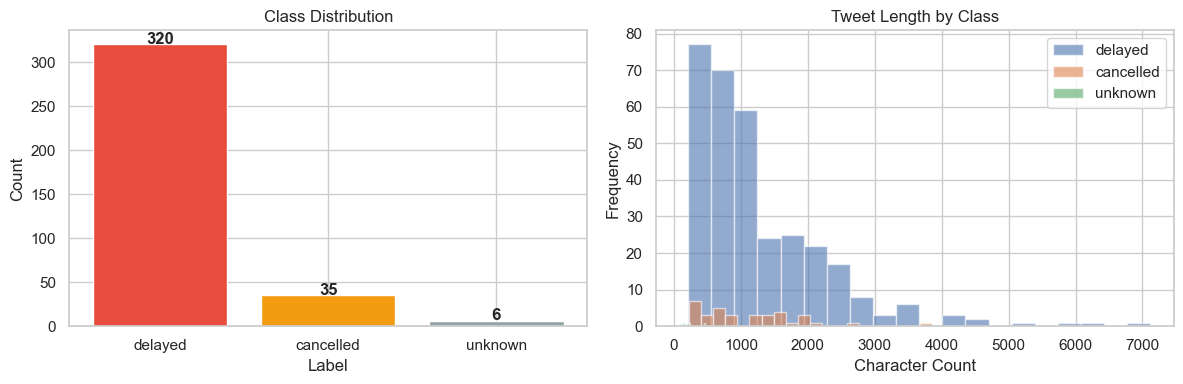


Tweet length stats:
           count    mean     std    min    25%     50%     75%     max
label                                                                 
cancelled   35.0  1112.9   801.5  216.0  532.0   885.0  1553.5  3855.0
delayed    320.0  1269.8  1026.0  209.0  566.2  1004.5  1729.2  7120.0
unknown      6.0   209.8   133.7   83.0  138.2   179.5   217.0   463.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df["label"].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=["#e74c3c", "#f39c12", "#95a5a6"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

# Tweet length distribution
df["text_length"] = df["text"].str.len()
for label in df["label"].unique():
    subset = df[df["label"] == label]["text_length"]
    axes[1].hist(subset, alpha=0.6, label=label, bins=20)
axes[1].set_title("Tweet Length by Class")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTweet length stats:\n{df.groupby('label')['text_length'].describe().round(1)}")


## 4. Train TF-IDF + Logistic Regression Model

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

X = df["text"]
y = df["label"]

# Train/test split — stratified to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train class distribution:\n{y_train.value_counts()}")

Train: 288 | Test: 73
Train class distribution:
label
delayed      255
cancelled     28
unknown        5
Name: count, dtype: int64


In [17]:
# Build pipeline: TF-IDF vectoriser → Logistic Regression
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        max_features=5000,
        sublinear_tf=True,    # apply log normalization to term frequencies
        strip_accents="unicode",
        lowercase=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # handles class imbalance
        random_state=42,
    )),
])

# Cross-validation on training set
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Train on full training set
pipeline.fit(X_train, y_train)

Cross-validation accuracy: 0.944 ± 0.020


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 5. Evaluate

In [23]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
results = X_test.to_frame()
results["actual"] = y_test.values
results["predicted"] = y_pred
results

Classification Report:
              precision    recall  f1-score   support

   cancelled       0.71      0.71      0.71         7
     delayed       0.97      0.98      0.98        65
     unknown       0.00      0.00      0.00         1

    accuracy                           0.95        73
   macro avg       0.56      0.57      0.56        73
weighted avg       0.93      0.95      0.94        73



/Users/jonelalobo/.pyenv/versions/3.11.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonelalobo/.pyenv/versions/3.11.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jonelalobo/.pyenv/versions/3.11.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

,text,actual,predicted
337,⚠️ #WesternLine Some trains are running late d...,cancelled,cancelled
301,⚠️ #NorthShoreLine #WesternLine Continue to al...,delayed,delayed
214,⚠ #NorthShoreLine #WesternLine Allow extra tra...,delayed,delayed
346,#NorthShoreLine allow extra travel time due to...,delayed,delayed
189,#WesternLine allow extra travel time due to ur...,delayed,delayed
...,...,...,...
38,#WesternLine #NorthShoreLine Allow plenty of e...,delayed,delayed
178,#WesternLine &amp; #NorthShoreLine Allow plent...,delayed,delayed
148,#WesternLine Allow up to 15 minutes extra trav...,delayed,delayed
199,⚠️ #NorthShoreLine allow an extra 20 minutes t...,delayed,delayed


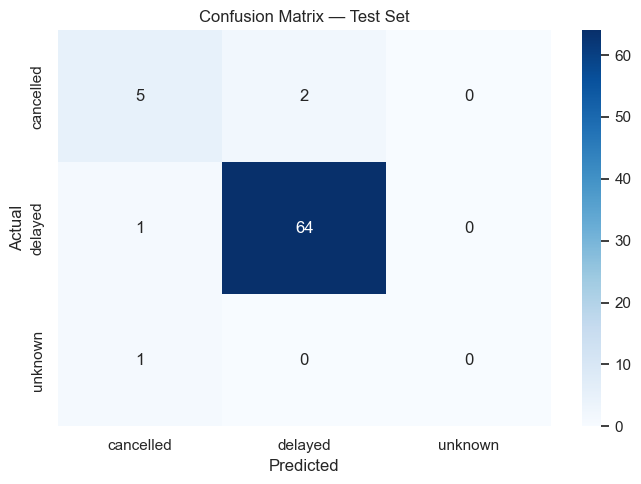

In [19]:
# Confusion matrix
labels = ["cancelled", "delayed", "unknown"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels, ax=ax
)
ax.set_title("Confusion Matrix — Test Set")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Top TF-IDF features per class
tfidf = pipeline.named_steps["tfidf"]
clf = pipeline.named_steps["clf"]
feature_names = tfidf.get_feature_names_out()

print("Top 10 features per class:")
for i, class_label in enumerate(clf.classes_):
    top_indices = np.argsort(clf.coef_[i])[-10:][::-1]
    top_features = [feature_names[j] for j in top_indices]
    print(f"  {class_label}: {top_features}")

Top 10 features per class:
  cancelled: ['buses', 'richmond', 'limited', 'running between', 'not', 'buses are', 'replace', 'are not', 'trains between', 'not running']
  delayed: ['may', 'time due', 'screens', 'information screens', 'northshoreline', 'earlier', 'listen', 'westernline allow', 'longer', 'northshoreline allow']
  unknown: ['for your', 've', 'to share', 'or for', 'share feedback', 'share', 'feedback', 'alex', 'here', 'at https']


In [21]:
# Compare ML model vs keyword baseline on the test set
y_keyword = X_test.apply(keyword_classify)

from sklearn.metrics import accuracy_score
ml_acc = accuracy_score(y_test, y_pred)
kw_acc = accuracy_score(y_test, y_keyword)

print(f"Keyword baseline accuracy : {kw_acc:.3f}")
print(f"TF-IDF + LR accuracy      : {ml_acc:.3f}")
print(f"Improvement               : {ml_acc - kw_acc:+.3f}")

Keyword baseline accuracy : 0.301
TF-IDF + LR accuracy      : 0.945
Improvement               : +0.644


## 6. Save Model

Saves the trained pipeline (vectoriser + classifier) to `model/tweet_classifier.pkl` for use in production.

In [22]:
import joblib
import os

os.makedirs("model", exist_ok=True)
joblib.dump(pipeline, "model/tweet_classifier.pkl")
print("Model saved to model/tweet_classifier.pkl")

# Sanity check: reload and predict
loaded_model = joblib.load("model/tweet_classifier.pkl")
test_tweets = [
    "T1 trains are cancelled due to a signal fault at Strathfield",
    "Expect minor delays on the T1 line this morning",
    "Good morning from Sydney Trains",
]
preds = loaded_model.predict(test_tweets)
for tweet, pred in zip(test_tweets, preds):
    print(f"  [{pred}] {tweet}")

Model saved to model/tweet_classifier.pkl
  [delayed] T1 trains are cancelled due to a signal fault at Strathfield
  [delayed] Expect minor delays on the T1 line this morning
  [delayed] Good morning from Sydney Trains


## 7. Updated `classify_tweet()` for Production

Drop-in replacement for the keyword classifier in `preprocessing_service.py`.
Load the model once at module level to avoid reloading on every call.

In [24]:
# Copy this into src/services/preprocessing_service.py

snippet = '''
import joblib
import os

# Load model once at module level
_MODEL_PATH = os.path.join(os.path.dirname(__file__), "../../model/tweet_classifier.pkl")
_classifier = joblib.load(_MODEL_PATH)


def classify_tweet(text: str) -> str:
    """
    Classify tweet text using TF-IDF + Logistic Regression model.

    Args:
        text (str): Tweet text to classify.

    Returns:
        str: Predicted classification label (cancelled / delayed / unknown).
    """
    prediction = _classifier.predict([text])
    return prediction[0]
'''

print(snippet)


import joblib
import os

# Load model once at module level
_MODEL_PATH = os.path.join(os.path.dirname(__file__), "../../model/tweet_classifier.pkl")
_classifier = joblib.load(_MODEL_PATH)


def classify_tweet(text: str) -> str:
    """
    Classify tweet text using TF-IDF + Logistic Regression model.

    Args:
        text (str): Tweet text to classify.

    Returns:
        str: Predicted classification label (cancelled / delayed / unknown).
    """
    prediction = _classifier.predict([text])
    return prediction[0]

